# 02 — Delivery reliability & customer satisfaction
### Olist Brazilian E-Commerce · `retail-platform-analytics`

The exploratory analysis (`01`) found the single strongest signal in the data: **late delivery
craters review scores** (on-time orders average 4.30★ vs 2.57★ for late). This notebook turns that
headline into a **defensible, controlled finding** and maps its geography. It covers three questions
from the EDA backlog:

- **A — What actually drives dissatisfaction?** Is it lateness itself, or confounders like shipping
  distance, item weight, or product category? We test with *controlled cuts*.
- **B — How accurate are the delivery estimates**, and does accuracy vary by region?
- **D — Is delivery *equitable* across Brazil**, or are some regions systematically underserved?

**Method:** descriptive analysis + controlled cuts (grouped breakdowns and correlations in SQL +
pandas). No predictive model — the goal is to *explain* the pattern transparently, not forecast it.

## Data caveats & conventions

- **Delivered orders only.** Delivery time, on-time status, and the estimate buffer only exist for
  orders that reached the customer, so this notebook filters to `status = 'delivered'` (~97% of orders).
- **Reliable window = Jan 2017 – Aug 2018** (partial edge months excluded elsewhere; here we use all
  delivered orders since delivery metrics are not time-trended).
- **Distance is computed, not given.** The marts dropped lat/long, so we rebuild a zip→coordinate
  lookup from `stg_geolocation` (averaging the multiple points per zip prefix) and compute the
  **great-circle (haversine) distance** between the seller's zip and the customer's zip. For
  multi-seller orders we take the average seller distance. Coverage is ~99% of orders.
- **Category per order** is the order's dominant item category (orders can span categories) — fine for
  a descriptive cut.
- **On-time** = delivered on or before the checkout `estimated_delivery_date`. **Buffer** = days the
  order arrived *earlier* than that estimate (positive = early).
- **⚠️ Correlation, not a controlled experiment.** Controlled cuts hold one confounder constant at a
  time; they strongly suggest causation here but do not prove it.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

print("Connected:", q("select current_schema() as s").iloc[0, 0])

Connected: DEV_MARTS


## 1. The signal we are chasing

First, reproduce the headline from `01` at the order level: the average review score for on-time vs
late deliveries. This is the effect the rest of the notebook interrogates.

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_47004/1121690128.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=headline, x="label", y="avg_score", ax=ax, palette=["#C44E52", "#55A868"])


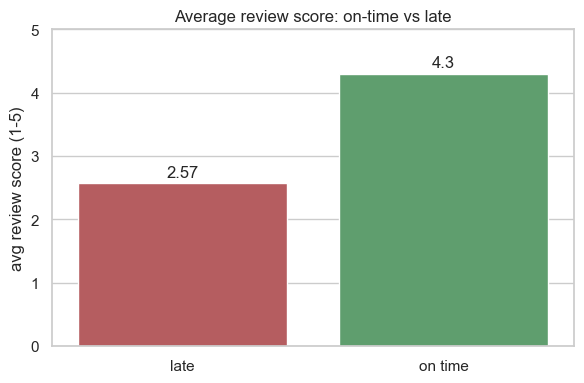

,label,orders,avg_score
0,late,7566,2.57
1,on time,87146,4.30


In [2]:
headline = q('''
    select is_delivered_on_time, count(*) as orders, round(avg(review_score), 2) as avg_score
    from dev_marts.fct_orders
    where status = 'delivered' and review_score is not null and is_delivered_on_time is not null
    group by 1 order by 1
''')
headline["label"] = headline["is_delivered_on_time"].map({True: "on time", False: "late"})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=headline, x="label", y="avg_score", ax=ax, palette=["#C44E52", "#55A868"])
ax.set_title("Average review score: on-time vs late"); ax.set_xlabel(""); ax.set_ylabel("avg review score (1-5)")
ax.set_ylim(0, 5)
for i, r in headline.iterrows():
    ax.text(i, r["avg_score"] + 0.1, f"{r['avg_score']}", ha="center")
plt.tight_layout(); plt.show()
headline[["label", "orders", "avg_score"]]

**A ~1.7-point gap** on a 5-point scale — enormous. But late orders might just be the *hard*
orders (far away, heavy, certain categories). The rest of this notebook asks whether the gap survives
once we control for those confounders.

## 2. Building seller → customer distance

The marts don't carry coordinates, so we reconstruct them from `stg_geolocation` and compute the
great-circle distance between each order's seller(s) and its delivery address. We pull **one
order-level dataframe** with everything we need (distance, weight, category, delivery metrics) and do
all the analysis from it in pandas — one heavy query instead of many.

In [3]:
orders = q('''
    with zip as (
        select zip_code_prefix, avg(latitude) as lat, avg(longitude) as lng
        from dev_staging.stg_geolocation group by 1
    ),
    order_seller as (select distinct order_id, seller_id from dev_marts.fct_order_items),
    seller_pt as (
        select os.order_id, z.lat as slat, z.lng as slng
        from order_seller os
        join dev_marts.dim_sellers s on os.seller_id = s.seller_id
        join zip z on s.zip_code_prefix = z.zip_code_prefix
    ),
    order_weight as (
        select oi.order_id, avg(p.weight_g) as weight_g, max(oi.category_name) as category_name
        from dev_marts.fct_order_items oi
        join dev_marts.dim_products p on oi.product_id = p.product_id
        group by 1
    ),
    base as (
        select o.order_id, o.delivery_state, o.status, o.delivery_time_days,
               o.is_delivered_on_time, o.review_score,
               datediff('day', o.delivered_to_customer_at, o.estimated_delivery_date) as est_buffer_days,
               zc.lat as clat, zc.lng as clng
        from dev_marts.fct_orders o
        join zip zc on o.delivery_zip_code_prefix = zc.zip_code_prefix
    )
    select b.order_id, b.delivery_state, b.status, b.delivery_time_days,
           b.is_delivered_on_time, b.review_score, b.est_buffer_days,
           w.weight_g, w.category_name,
           avg(2 * 6371 * asin(sqrt(
               pow(sin(radians(b.clat - sp.slat) / 2), 2)
               + cos(radians(sp.slat)) * cos(radians(b.clat))
               * pow(sin(radians(b.clng - sp.slng) / 2), 2)))) as dist_km
    from base b
    left join seller_pt sp on b.order_id = sp.order_id
    left join order_weight w on b.order_id = w.order_id
    group by 1, 2, 3, 4, 5, 6, 7, 8, 9
''')

# Clean types and restrict to delivered orders with a review
for c in ["delivery_time_days", "review_score", "est_buffer_days", "weight_g", "dist_km"]:
    orders[c] = pd.to_numeric(orders[c], errors="coerce")
orders["on_time"] = orders["is_delivered_on_time"].astype("boolean")

d = orders[(orders["status"] == "delivered") & orders["dist_km"].notna()].copy()
print(f"{len(orders):,} orders pulled | {len(d):,} delivered with distance "
      f"({100*len(d)/len(orders):.1f}% coverage)")
print(f"median distance {d['dist_km'].median():.0f} km | mean {d['dist_km'].mean():.0f} km")

99,163 orders pulled | 96,002 delivered with distance (96.8% coverage)
median distance 434 km | mean 601 km


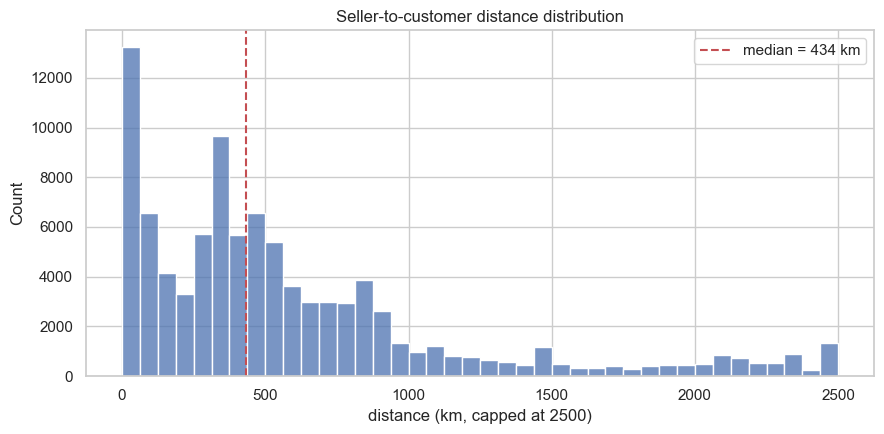

In [4]:
fig, ax = plt.subplots()
sns.histplot(d["dist_km"].clip(upper=2500), bins=40, color="#4C72B0", ax=ax)
ax.axvline(d["dist_km"].median(), color="#C44E52", ls="--", label=f"median = {d['dist_km'].median():.0f} km")
ax.set_title("Seller-to-customer distance distribution")
ax.set_xlabel("distance (km, capped at 2500)"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Delivery performance by distance

Bucket orders by distance and look at delivery time, on-time rate, and review score together.

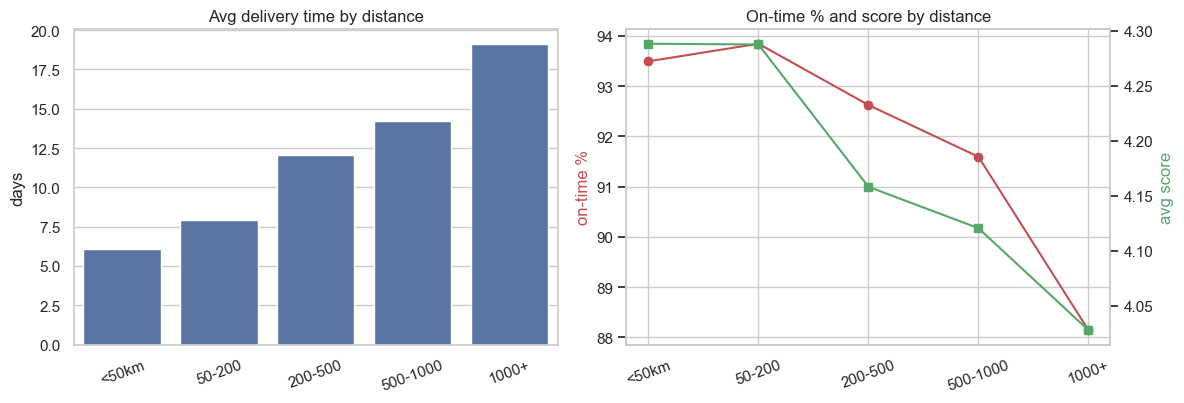

,dist_bucket,orders,avg_days,on_time_pct,avg_score
0,<50km,11665,6.10,93.49,4.29
1,50-200,12898,7.94,93.84,4.29
2,200-500,30314,12.05,92.62,4.16
3,500-1000,25753,14.25,91.59,4.12
4,1000+,15349,19.09,88.14,4.03


In [5]:
d["dist_bucket"] = pd.cut(d["dist_km"], [0, 50, 200, 500, 1000, np.inf],
                           labels=["<50km", "50-200", "200-500", "500-1000", "1000+"])
by_dist = d.groupby("dist_bucket", observed=True).agg(
    orders=("order_id", "size"),
    avg_days=("delivery_time_days", "mean"),
    on_time_pct=("on_time", "mean"),
    avg_score=("review_score", "mean")).reset_index()
by_dist["on_time_pct"] *= 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(data=by_dist, x="dist_bucket", y="avg_days", ax=ax1, color="#4C72B0")
ax1.set_title("Avg delivery time by distance"); ax1.set_xlabel(""); ax1.set_ylabel("days")
ax1.tick_params(axis="x", rotation=20)
ax2.plot(by_dist["dist_bucket"], by_dist["on_time_pct"], marker="o", color="#C44E52", label="on-time %")
ax2b = ax2.twinx()
ax2b.plot(by_dist["dist_bucket"], by_dist["avg_score"], marker="s", color="#55A868", label="avg score")
ax2.set_ylabel("on-time %", color="#C44E52"); ax2b.set_ylabel("avg score", color="#55A868")
ax2.set_title("On-time % and score by distance"); ax2.tick_params(axis="x", rotation=20); ax2b.grid(False)
plt.tight_layout(); plt.show()
by_dist.round(2)

**Interpretation.** A clean monotonic gradient: distance roughly **triples delivery time**
(~6 days under 50km → ~19 days beyond 1000km), drops on-time rate (~94% → ~88%), and pulls review
scores down (~4.29 → ~4.03). Distance clearly hurts the customer experience — but *through what
mechanism*? The next section isolates it.

## 4. Is it distance, or is it lateness? (controlled cut #1)

If distance hurt scores *directly*, then even **on-time** far-away orders would score poorly. If
distance hurts scores only *by causing lateness*, then within each distance band the on-time vs late
gap should stay large and the on-time score should stay high regardless of distance. We test exactly
that.

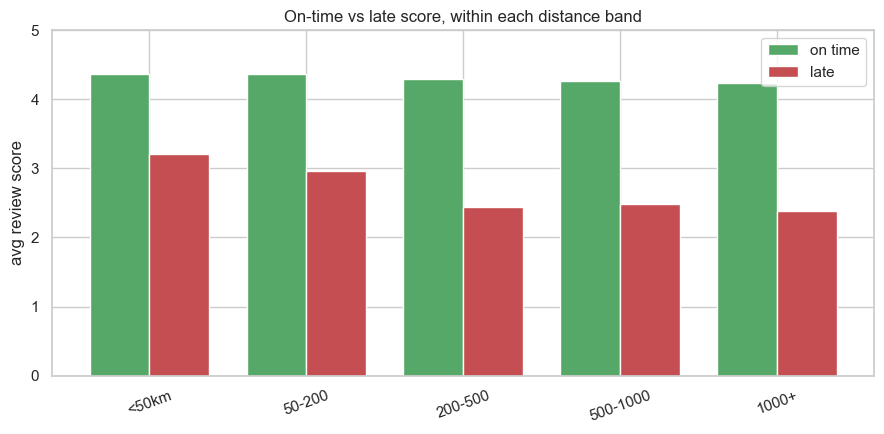

on_time,dist_bucket,late_score,ontime_score,gap
0,<50km,3.20,4.36,1.16
1,50-200,2.96,4.37,1.41
2,200-500,2.45,4.29,1.85
3,500-1000,2.48,4.27,1.79
4,1000+,2.38,4.24,1.86


In [6]:
def gap_table(frame, by):
    f = frame.dropna(subset=["review_score", "on_time"]).copy()
    f["on_time"] = f["on_time"].astype(bool)
    g = f.groupby([by, "on_time"], observed=True)["review_score"].mean().unstack()
    g = g.rename(columns={True: "ontime_score", False: "late_score"})
    g["gap"] = g["ontime_score"] - g["late_score"]
    return g.reset_index()

dist_gap = gap_table(d, "dist_bucket")

fig, ax = plt.subplots()
x = np.arange(len(dist_gap)); w = 0.38
ax.bar(x - w/2, dist_gap["ontime_score"], w, label="on time", color="#55A868")
ax.bar(x + w/2, dist_gap["late_score"], w, label="late", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(dist_gap["dist_bucket"], rotation=20)
ax.set_ylim(0, 5); ax.set_ylabel("avg review score"); ax.set_title("On-time vs late score, within each distance band")
ax.legend()
plt.tight_layout(); plt.show()
dist_gap.round(2)

**Interpretation — the key finding.** Hold distance constant and the story is unmistakable:
**on-time orders score ~4.2–4.4 in every distance band**, while **late orders score ~2.4–3.1**
everywhere. The ~1.7-point penalty is *not* explained by distance — a far-away order that still
arrives on time is rated almost as highly as a local one. **Distance matters only because it makes
orders late.** Lateness is the lever; distance is one cause of it.

## 5. Robustness: controlling for weight and category

A good controlled finding holds under *multiple* controls. Repeat the on-time/late cut within item
**weight** bands and top **categories**.

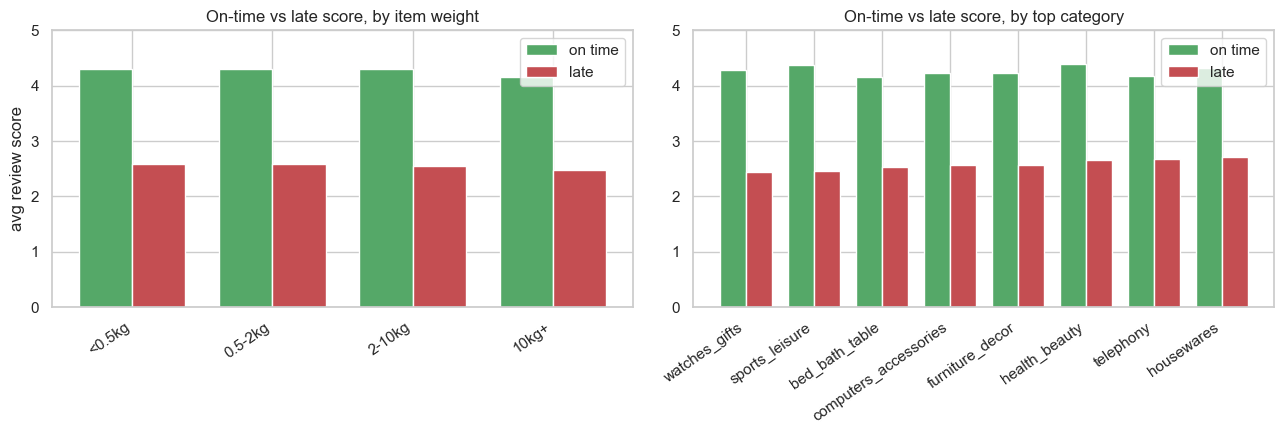

on_time,weight_bucket,late_score,ontime_score,gap
0,<0.5kg,2.58,4.31,1.73
1,0.5-2kg,2.58,4.31,1.72
2,2-10kg,2.54,4.29,1.75
3,10kg+,2.47,4.16,1.69


In [7]:
d["weight_bucket"] = pd.cut(d["weight_g"], [0, 500, 2000, 10000, np.inf],
                             labels=["<0.5kg", "0.5-2kg", "2-10kg", "10kg+"])
weight_gap = gap_table(d, "weight_bucket")

top_cats = d["category_name"].value_counts().head(8).index
cat_gap = gap_table(d[d["category_name"].isin(top_cats)], "category_name").sort_values("late_score")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, tbl, key, ttl in [(ax1, weight_gap, "weight_bucket", "by item weight"),
                          (ax2, cat_gap, "category_name", "by top category")]:
    x = np.arange(len(tbl)); w = 0.38
    ax.bar(x - w/2, tbl["ontime_score"], w, label="on time", color="#55A868")
    ax.bar(x + w/2, tbl["late_score"], w, label="late", color="#C44E52")
    ax.set_xticks(x); ax.set_xticklabels(tbl[key], rotation=35, ha="right")
    ax.set_ylim(0, 5); ax.set_title(f"On-time vs late score, {ttl}"); ax.legend()
ax1.set_ylabel("avg review score")
plt.tight_layout(); plt.show()
weight_gap.round(2)

**Interpretation.** Same pattern under every control: **on-time ≈ 4.3★, late ≈ 2.5★** across all
weight bands and across every major category. Heavier items and certain categories deliver slower (and
so go late more often), but *conditional on being late*, the satisfaction hit is uniform. The
lateness→dissatisfaction effect is **robust** — it is not a proxy for distance, weight, or category.

## 6. How accurate are the delivery estimates? (question B)

Olist shows customers an `estimated_delivery_date` at checkout. From `01` we know orders arrive ~12
days *early* on average — estimates are conservative overall. But is that padding **evenly
distributed**, or do some regions get tight (risky) estimates? The **buffer** = days earlier than
promised (positive = arrived early).

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_47004/2995474419.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=est_sorted, x="state", y="avg_buffer_days", ax=ax, palette=colors, order=est_sorted["state"])


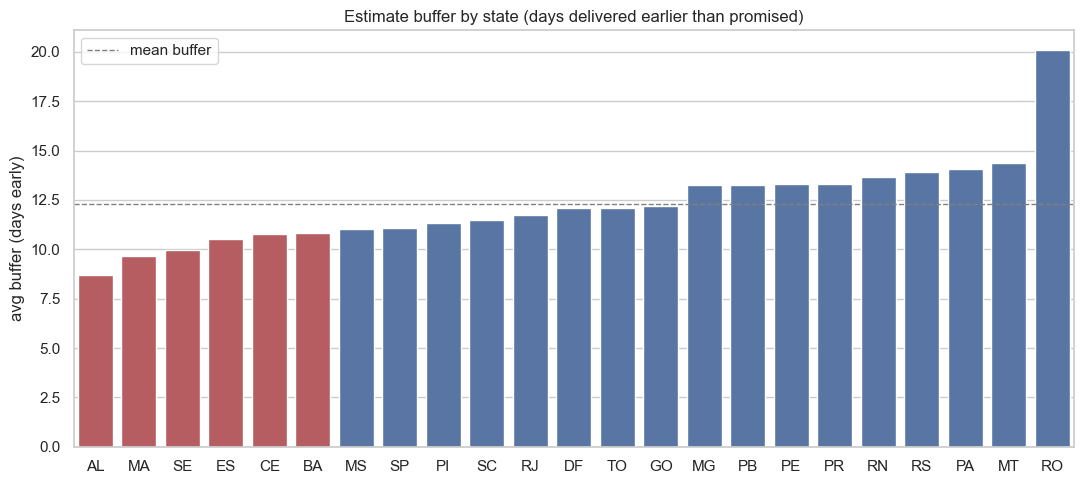

,state,orders,avg_buffer_days,on_time_pct,avg_delivery_days
16,AL,396,8.70,76.00,24.50
14,MA,714,9.60,80.50,21.40
11,SE,334,10.00,84.70,21.50
19,ES,1989,10.50,87.90,15.70
3,CE,1275,10.80,84.60,21.20
9,BA,3248,10.80,86.10,19.30


In [8]:
est = q('''
    select delivery_state as state, count(*) as orders,
           avg(datediff('day', delivered_to_customer_at, estimated_delivery_date)) as avg_buffer_days,
           avg(iff(is_delivered_on_time, 1, 0)) * 100 as on_time_pct,
           avg(delivery_time_days) as avg_delivery_days
    from dev_marts.fct_orders
    where status = 'delivered' and delivered_to_customer_at is not null and delivery_state is not null
    group by 1 having count(*) >= 200
''')
est_sorted = est.sort_values("avg_buffer_days")

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#C44E52" if b < 11 else "#4C72B0" for b in est_sorted["avg_buffer_days"]]
sns.barplot(data=est_sorted, x="state", y="avg_buffer_days", ax=ax, palette=colors, order=est_sorted["state"])
ax.axhline(est_sorted["avg_buffer_days"].mean(), color="grey", ls="--", lw=1, label="mean buffer")
ax.set_title("Estimate buffer by state (days delivered earlier than promised)")
ax.set_xlabel(""); ax.set_ylabel("avg buffer (days early)"); ax.legend()
plt.tight_layout(); plt.show()
est_sorted.head(6).round(1)

**Interpretation.** The padding is **not** even. Northern/northeastern states (AL, MA, SE, PA)
get the **smallest buffers *and* the lowest on-time rates (~76–85%)** — they are both slowest to
deliver *and* given the least cushion, so they miss the promise most often. Southern/central states
(RO, MT, RS) get double-digit buffers and 93–97% on-time. The estimate model appears tuned to the
high-volume Southeast and under-serves the periphery.

## 7. Geographic delivery equity (question D)

Pull the delivery experience together by state — volume, speed, reliability, and satisfaction — and
ask how much of the variation distance alone explains.

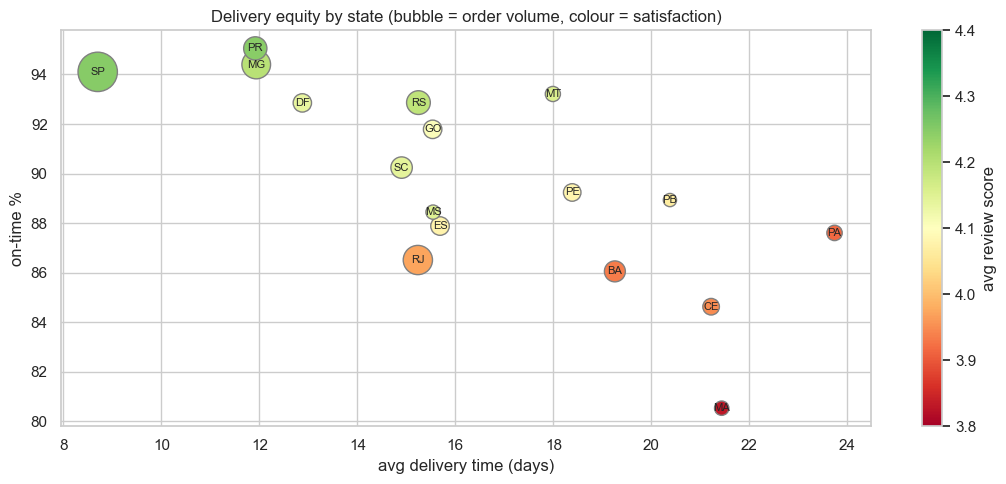

,state,orders,avg_days,on_time_pct,avg_score
5,SP,40480,8.70,94.11,4.25
10,RJ,12337,15.23,86.51,3.97
7,MG,11345,11.94,94.40,4.20
1,RS,5340,15.25,92.87,4.19
6,PR,4912,11.92,95.05,4.25
14,SC,3546,14.90,90.24,4.14
9,BA,3248,19.26,86.05,3.93
11,ES,1989,15.69,87.88,4.08
0,GO,1948,15.54,91.79,4.11
15,DF,1917,12.88,92.85,4.14


In [9]:
state = q('''
    select delivery_state as state, count(*) as orders,
           avg(delivery_time_days) as avg_days,
           avg(iff(is_delivered_on_time, 1, 0)) * 100 as on_time_pct,
           avg(review_score) as avg_score
    from dev_marts.fct_orders
    where status = 'delivered' and delivery_time_days is not null and delivery_state is not null
    group by 1 having count(*) >= 500
''').sort_values("orders", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(state["avg_days"], state["on_time_pct"],
                s=np.sqrt(state["orders"]) * 4, c=state["avg_score"], cmap="RdYlGn", vmin=3.8, vmax=4.4,
                edgecolor="grey")
for _, r in state.iterrows():
    ax.annotate(r["state"], (r["avg_days"], r["on_time_pct"]), fontsize=8, ha="center", va="center")
plt.colorbar(sc, label="avg review score")
ax.set_xlabel("avg delivery time (days)"); ax.set_ylabel("on-time %")
ax.set_title("Delivery equity by state (bubble = order volume, colour = satisfaction)")
plt.tight_layout(); plt.show()
state.round(2).head(12)

In [10]:
corr = d["dist_km"].corr(d["delivery_time_days"])
print(f"Correlation(distance, delivery time) = {corr:.3f}")

Correlation(distance, delivery time) = 0.394


**Interpretation.** Delivery is clearly **inequitable**. São Paulo (the hub) delivers in ~8.7
days at 94% on-time / 4.25★; remote Ceará and Bahia take ~19–21 days at ~85% on-time / ~3.9★. But
distance is not the whole story — the correlation between distance and delivery time is only **~0.39**,
and **Rio de Janeiro is the tell**: it's close to São Paulo yet slow (~15 days, 86% on-time, 3.97★),
worse than several far-flung states. That points to **logistics/infrastructure bottlenecks** (customs
of scale, congestion, carrier hand-offs) beyond raw distance.

## 8. Findings & recommendations

### What we established
1. **Lateness is the causal driver of dissatisfaction**, not distance/weight/category. Controlling for
   each, on-time orders score ~4.3★ and late orders ~2.5★ *everywhere* — a robust ~1.7-point penalty.
2. **Distance drives lateness, partially.** It triples delivery time and raises the miss rate, but
   explains only ~39% of delivery-time variation. On-time far orders keep customers nearly as happy.
3. **Estimates are inequitably padded.** Remote north/northeast states get the tightest buffers *and*
   the slowest delivery — a double penalty that maximises broken promises where reliability is worst.
4. **Delivery is geographically inequitable**, and RJ shows it's not just distance — infrastructure
   matters (RJ is near the hub yet slow).

### Recommendations (if this were a live platform)
- **Protect on-time performance on long routes** — it's the lever that preserves satisfaction; a fast,
  reliable far-away delivery scores like a local one.
- **Re-pad estimates for underserved states** (AL, MA, SE, PA): widen the promised window so the
  on-time rate recovers, rather than chasing unrealistic speed.
- **Investigate the RJ bottleneck** — a same-region slowdown suggests a fixable logistics issue, not a
  geography problem.

### Backlog update (next notebooks)
- `03_customer_segmentation_rfm.ipynb` — RFM segmentation (recency/frequency/monetary), the standalone
  analytics-engineering showcase.
- `04_category_and_freight_economics.ipynb` — freight-as-margin-proxy *by category and weight*
  (deepening the overall trend shown in `01`).